<a href="https://colab.research.google.com/github/bhumikashiriya-dot/Lnt-task-/blob/main/Task%201%20Copy_of_scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train.reshape(-1, 784) / 255.0, x_test.reshape(-1, 784) / 255.0

opts = {"SGD": lambda lr: keras.optimizers.SGD(lr),
        "Momentum": lambda lr: keras.optimizers.SGD(lr, momentum=0.9),
        "RMSProp": lambda lr: keras.optimizers.RMSprop(lr),
        "Adam": lambda lr: keras.optimizers.Adam(lr)}
results, hist = [], {}

def run(name, layers=2, neurons=128, act="relu", opt="Adam", lr=0.001, bs=128, epochs=5, n=60000):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([keras.Input(shape=(784,))] +
                         [keras.layers.Dense(neurons, activation=act) for _ in range(layers)] +
                         [keras.layers.Dense(10, activation="softmax")])
    m.compile(opts[opt](lr), "sparse_categorical_crossentropy", metrics=["accuracy"])
    h = m.fit(x_train[:n], y_train[:n], epochs=epochs, batch_size=bs, validation_split=0.1, verbose=0)
    loss, acc = m.evaluate(x_test, y_test, verbose=0)
    results.append(dict(run=name, layers=layers, neurons=neurons, act=act, opt=opt, lr=lr,
                        batch_size=bs, test_acc=round(acc, 4), test_loss=round(loss, 4)))
    hist[name] = h.history
    print(name, round(acc, 4))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
run("single-layer", layers=0)
run("multi-layer")

for o in opts:                                   # 4 optimizers
    run(f"opt={o}", opt=o, lr=0.01 if o in ("SGD", "Momentum") else 0.001)

run("Batch", opt="SGD", lr=0.1, n=5000, bs=5000, epochs=100)      # batch GD
run("Mini-batch", opt="SGD", lr=0.1, n=5000, bs=32, epochs=10)    # mini-batch GD
run("Stochastic", opt="SGD", lr=0.01, n=5000, bs=1, epochs=3)     # stochastic GD

for lr in [0.1, 0.01, 0.001]: run(f"lr={lr}", lr=lr)              # tuning
for bs in [32, 512]: run(f"bs={bs}", bs=bs)
for nn in [32, 256]: run(f"neurons={nn}", neurons=nn)
for a in ["tanh", "sigmoid"]: run(f"act={a}", act=a)

single-layer 0.9236
multi-layer 0.9713
opt=SGD 0.9135
opt=Momentum 0.9623
opt=RMSProp 0.9737
opt=Adam 0.9713
Batch 0.8866
Mini-batch 0.9294
Stochastic 0.9202
lr=0.1 0.4584
lr=0.01 0.9632
lr=0.001 0.9713
bs=32 0.9739
bs=512 0.9657
neurons=32 0.9581
neurons=256 0.9741
act=tanh 0.9714
act=sigmoid 0.9574


,run,layers,neurons,act,opt,lr,batch_size,test_acc,test_loss
0,single-layer,0,128,relu,Adam,0.001,128,0.9236,0.2800
1,multi-layer,2,128,relu,Adam,0.001,128,0.9713,0.0938
2,opt=SGD,2,128,relu,SGD,0.010,128,0.9135,0.2995
3,opt=Momentum,2,128,relu,Momentum,0.010,128,0.9623,0.1226
4,opt=RMSProp,2,128,relu,RMSProp,0.001,128,0.9737,0.0861
5,opt=Adam,2,128,relu,Adam,0.001,128,0.9713,0.0938
6,Batch,2,128,relu,SGD,0.100,5000,0.8866,0.4101
7,Mini-batch,2,128,relu,SGD,0.100,32,0.9294,0.2496
8,Stochastic,2,128,relu,SGD,0.010,1,0.9202,0.2643
9,lr=0.1,2,128,relu,Adam,0.100,128,0.4584,1.2740


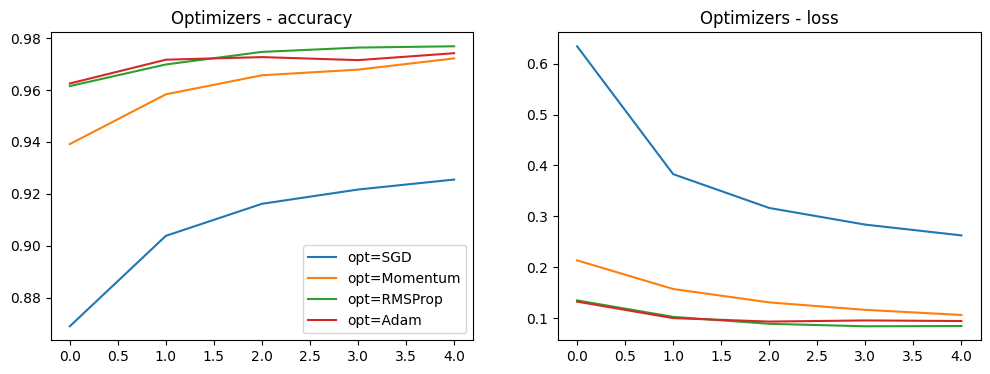

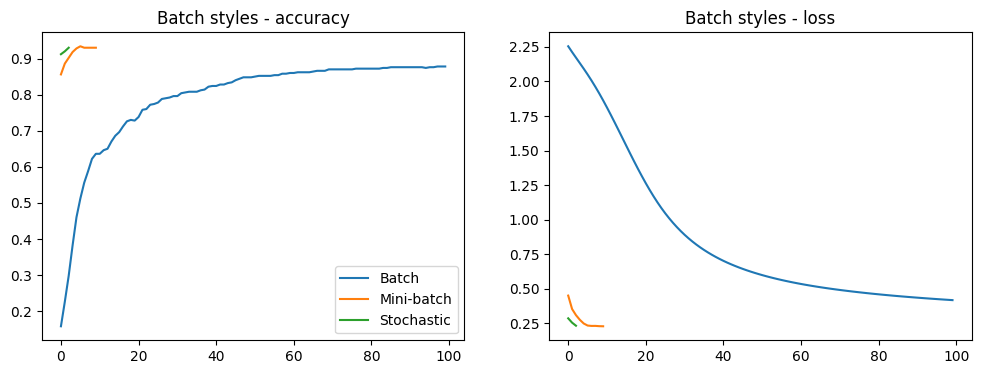

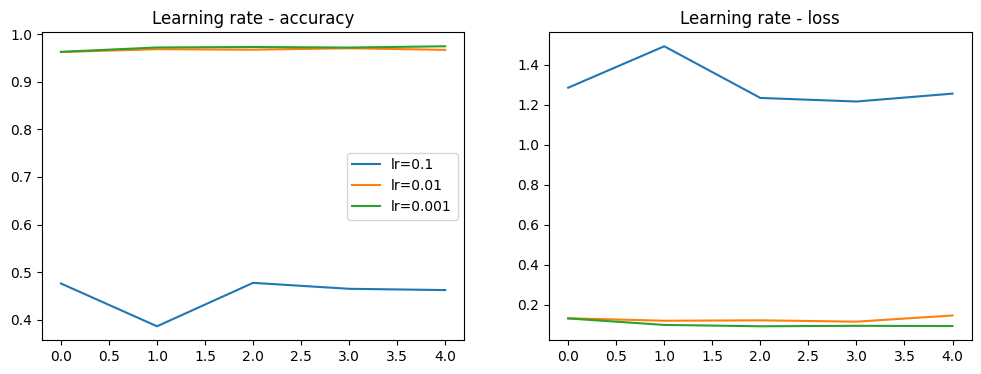

In [ ]:
df = pd.DataFrame(results)
display(df)

def plot(keys, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for k in keys:
        ax[0].plot(hist[k]["val_accuracy"], label=k)
        ax[1].plot(hist[k]["val_loss"], label=k)
    ax[0].set_title(title + " - accuracy"); ax[1].set_title(title + " - loss")
    ax[0].legend(); plt.show()

plot([k for k in hist if k.startswith("opt=")], "Optimizers")
plot(["Batch", "Mini-batch", "Stochastic"], "Batch styles")
plot([k for k in hist if k.startswith("lr=")], "Learning rate")

In [ ]:
rng = np.random.default_rng(0)
W1, b1 = rng.normal(0, .05, (784, 64)), np.zeros(64)
W2, b2 = rng.normal(0, .05, (64, 10)), np.zeros(10)

def forward(X):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    e = np.exp(z2 - z2.max(1, keepdims=True))
    return z1, a1, e / e.sum(1, keepdims=True)

for ep in range(10):
    idx = rng.permutation(60000)
    for i in range(0, 60000, 128):
        b = idx[i:i+128]
        X, Y = x_train[b], np.eye(10)[y_train[b]]
        z1, a1, p = forward(X)                  # forward propagation
        dz2 = (p - Y) / len(b)                  # backpropagation
        dW2, db2 = a1.T @ dz2, dz2.sum(0)
        dz1 = (dz2 @ W2.T) * (z1 > 0)
        dW1, db1 = X.T @ dz1, dz1.sum(0)
        W1 -= .1 * dW1; b1 -= .1 * db1          # weight update
        W2 -= .1 * dW2; b2 -= .1 * db2
    print("epoch", ep + 1, "test acc", (forward(x_test)[2].argmax(1) == y_test).mean())

epoch 1 test acc 0.9106
epoch 2 test acc 0.9248
epoch 3 test acc 0.9343
epoch 4 test acc 0.9408
epoch 5 test acc 0.9478
epoch 6 test acc 0.9505
epoch 7 test acc 0.955
epoch 8 test acc 0.9568
epoch 9 test acc 0.9602
epoch 10 test acc 0.9627


## Comparative Analysis

**Single vs multi-layer:** The multi-layer network (2 hidden layers) reached 97.13% test accuracy with a loss of 0.0938, compared with 92.36% and 0.2800 for the single-layer network. The hidden layers let the model learn non-linear features of the digits, which a single softmax layer cannot.

**Optimizers:** RMSProp performed best (97.37%, loss 0.0861), closely followed by Adam (97.13%) and Momentum (96.23%). Plain SGD was clearly the weakest (91.35%, loss 0.2995). SGD uses one fixed step size, so it converges slowly. Momentum smooths the updates, and RMSProp and Adam adapt the step size for each weight, so they converge fastest, as the accuracy and loss curves show.

**Batch styles (5,000-sample subset):** Mini-batch (32) gave the best result at 92.94%. Stochastic (batch size 1) reached 92.02% and full-batch reached only 88.66%. Full-batch makes just one weight update per epoch, so it was still improving slowly when training ended. Stochastic makes an update after every sample, so it learns quickly but is noisy and needs many more updates per epoch. Mini-batch balances speed and stability. These runs used a small subset and different learning rates and epochs, so they are indicative rather than exact.

**Hyperparameter tuning:**
- **Learning rate:** 0.001 was best (97.13%). 0.01 gave 96.32%. 0.1 failed to train properly (45.84%, loss 1.27) because the steps were too large and overshot the minimum.
- **Batch size:** 32 gave 97.39%, 128 gave 97.13% and 512 gave 96.57%. Smaller batches update more often and generalize slightly better.
- **Neurons:** 32 gave 95.81%, 128 gave 97.13% and 256 gave 97.41% (loss 0.0850, the lowest of all runs). More neurons help, with diminishing returns.
- **Activation:** ReLU (97.13%) and tanh (97.14%) performed almost identically. Sigmoid reached ___%, which is slightly lower because it suffers from vanishing gradients.

**From-scratch NumPy network:** The forward and backpropagation implementation (784-64-10, ReLU, mini-batch gradient descent) reached 96.27% test accuracy after 10 epochs, close to the Keras models. This confirms the backpropagation is implemented correctly.

**Conclusion:** The most important settings were the optimizer and the learning rate. Adam or RMSProp with a learning rate of 0.001, mini-batch training, and 2 hidden layers with 128-256 ReLU neurons gave the best results (about 97.1-97.4% test accuracy). The best single run was 256 neurons at 97.41%. Differences of about 0.1% between the top runs are small and may be within random variation (each experiment was run with one seed).